## 1. Import libraries and check GPU

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("TensorFlow", tf.__version__, "| GPU:", gpus)


TensorFlow 2.10.1 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
print("TensorFlow version:", tf.__version__)

# Cố định random seed để chạy lại cho kết quả giống nhau
SEED = 42
tf.keras.utils.set_random_seed(SEED)

TensorFlow version: 2.10.1


## 2. Loading and explore the dataset

Categories: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


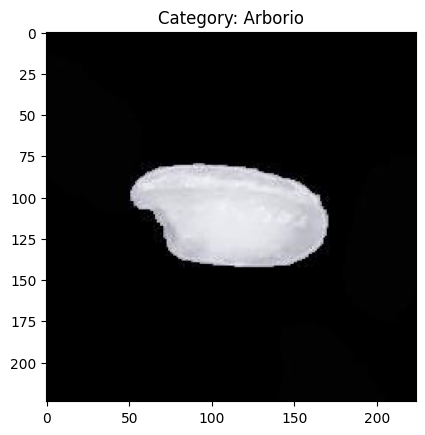

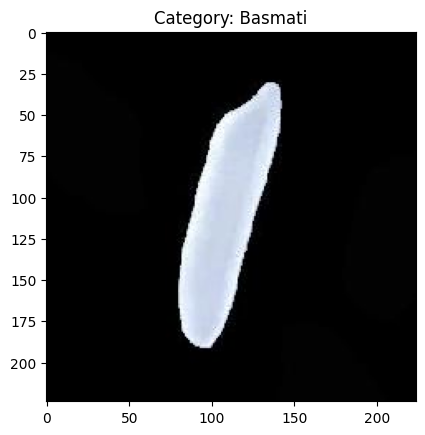

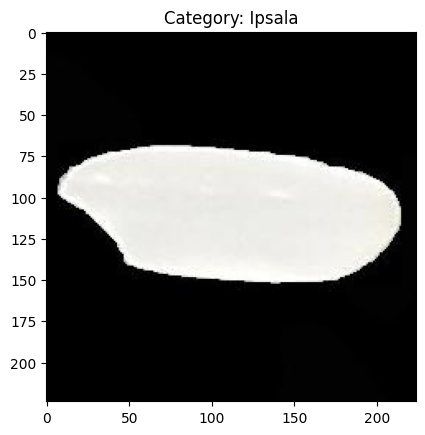

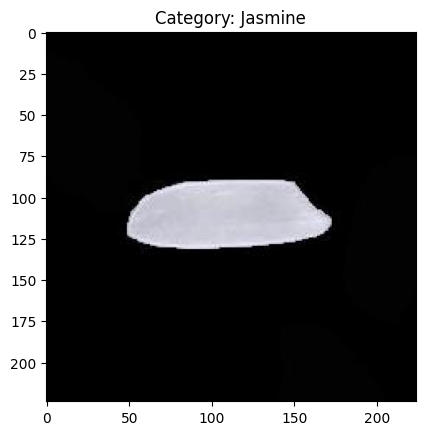

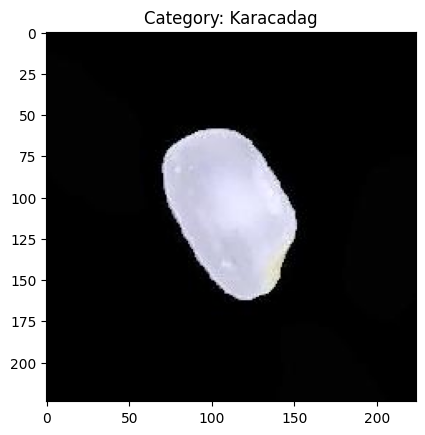

In [4]:
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Define the dataset path
dataset_path = r"D:\Rice_DL_Project\Rice_Classification\data\raw\Rice_Image_Dataset"  

# Explore the dataset
categories = [category for category in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, category))]
print("Categories:", categories)

# Visualize some sample images from each category
for category in categories:
    category_path = os.path.join(dataset_path, category)
    sample_image = os.listdir(category_path)[0]  # Pick one image from each category
    img = image.load_img(os.path.join(category_path, sample_image), target_size=(224, 224))
    plt.imshow(img)
    plt.title(f"Category: {category}")
    plt.show()

## 3. Data quality check

Check class balance, corrupt files, image size/mode and duplicate files (MD5). Duplicates are removed before splitting to avoid train/test leakage.

In [ ]:
from PIL import Image
import hashlib

rows = []
for category in sorted(categories):
    folder = os.path.join(dataset_path, category)
    for fname in sorted(os.listdir(folder)):
        path = os.path.join(folder, fname)
        try:
            with Image.open(path) as im:
                im.verify()                      # detect corrupt files
            with Image.open(path) as im:
                size, mode = im.size, im.mode
            with open(path, "rb") as f:
                md5 = hashlib.md5(f.read()).hexdigest()
            rows.append((path, category, size, mode, md5))
        except Exception as e:
            print("Corrupt:", path, e)

info = pd.DataFrame(rows, columns=["filepath", "label", "size", "mode", "md5"])
print("Images per class:\n", info["label"].value_counts(), "\n")
print("Image sizes:\n", info["size"].value_counts(), "\n")
print("Color modes:\n", info["mode"].value_counts(), "\n")
print("Duplicate files:", info["md5"].duplicated().sum())
print("Duplicate groups with conflicting labels:", (info.groupby("md5")["label"].nunique() > 1).sum())

# Drop conflicting-label groups, then keep one copy of each duplicate
conflict = info.groupby("md5")["label"].transform("nunique") > 1
clean_df = info[~conflict].drop_duplicates("md5").reset_index(drop=True)
print(f"Kept {len(clean_df)} of {len(info)} images")

Images per class:
 label
Arborio      15000
Basmati      15000
Ipsala       15000
Jasmine      15000
Karacadag    15000
Name: count, dtype: int64 

Image sizes:
 size
(250, 250)    75000
Name: count, dtype: int64 

Color modes:
 mode
RGB    75000
Name: count, dtype: int64 

Duplicate files: 297
Duplicate groups with conflicting labels: 0
Kept 74703 of 75000 images


## 4. Data Preprocessing

Same 70/15/15 stratified split as Model 1 (same test set). MobileNetV2 expects pixels in [-1, 1], so its own `preprocess_input` is used instead of `rescale=1./255`. Augmentation is applied to the train generator only; val/test are not shuffled.
Random seed được cố định bằng `SEED` (split và generator).

In [ ]:
# Use the cleaned (filepath, label) table from the data quality check
df = clean_df[["filepath", "label"]]

# Split 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# No brightness/color/zoom changes: color is a key feature between rice varieties
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
)
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)   # val and test

def make_generator(data, datagen, shuffle):
    return datagen.flow_from_dataframe(
        data,
        x_col="filepath",
        y_col="label",
        target_size=(224, 224),
        batch_size=32,
        class_mode="categorical",
        shuffle=shuffle,
        seed=SEED,
    )

train_generator = make_generator(train_df, train_datagen, shuffle=True)
validation_generator = make_generator(val_df, eval_datagen, shuffle=False)
test_generator = make_generator(test_df, eval_datagen, shuffle=False)

Train: 52292 | Val: 11205 | Test: 11206
Found 52292 validated image filenames belonging to 5 classes.
Found 11205 validated image filenames belonging to 5 classes.
Found 11206 validated image filenames belonging to 5 classes.


## 5. Transfer learning model

MobileNetV2 (ImageNet) as a frozen backbone, with a new head for 5 classes. The backbone is called with `training=False` so BatchNorm stays in inference mode.

In [ ]:
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)   # keep BatchNorm in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation="softmax")(x)
model = models.Model(inputs, outputs)

9406464/9406464 [==============================] - 2s 0us/step


### Model summary for the report

- **Backbone:** MobileNetV2 pretrained on ImageNet (`include_top=False`, 7x7x1280 features).
- **Why:** lightweight (about 2.26M parameters), strong ImageNet features, fast to fine-tune on a single GPU.
- **Stage 1:** backbone frozen, only the head `Dense(5)` is trained (Adam lr=1e-3).
- **Stage 2:** the last 30 layers of the backbone (roughly the final blocks and `Conv_1`) are unfrozen, except BatchNorm layers which stay frozen. Adam lr=1e-5, model re-compiled.

## 6. Compiling the model (stage 1)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2,264,389
Trainable params: 6,405
Non-trainable

## 7. Model Training

Two stages: (1) train the head only, (2) fine-tune the last backbone layers with a much smaller learning rate. If a saved model exists it is loaded instead of retraining (set `FORCE_RETRAIN = True` to retrain).

In [ ]:
import json

def count_trainable(m):
    return int(sum(np.prod(w.shape) for w in m.trainable_weights))

FORCE_RETRAIN = False
models_dir = r"D:\Rice_DL_Project\Rice_Classification\models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "model3_transfer.h5")
history_path = os.path.join(models_dir, "model3_transfer_history.json")

if os.path.exists(model_path) and os.path.exists(history_path) and not FORCE_RETRAIN:
    # Reuse the saved model and its training history
    model = tf.keras.models.load_model(model_path, compile=False)
    with open(history_path) as f:
        history_dict = json.load(f)
    print("Loaded saved model:", model_path)
else:
    # Stage 1: train the head only (backbone frozen)
    print("Stage 1 trainable params:", count_trainable(model))   # expected ~6.4k
    early_stop1 = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    h1 = model.fit(
        train_generator,
        epochs=5,
        validation_data=validation_generator,
        callbacks=[early_stop1],
    )

    # Stage 2: fine-tune the last 30 backbone layers
    base_model.trainable = True
    for layer in base_model.layers[:-30]:
        layer.trainable = False                    # keep early layers frozen
    for layer in base_model.layers[-30:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False                # keep BN frozen

    # Re-compile is required for the trainable change to take effect
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),   # much smaller lr
                  loss="categorical_crossentropy", metrics=["accuracy"])
    print("Stage 2 trainable params:", count_trainable(model))

    early_stop2 = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    h2 = model.fit(
        train_generator,
        epochs=5,
        validation_data=validation_generator,
        callbacks=[early_stop2],
    )

    # Merge both stages; "stage" marks which stage each epoch belongs to
    history_dict = {k: h1.history[k] + h2.history[k] for k in h1.history}
    history_dict["stage"] = [1] * len(h1.history["loss"]) + [2] * len(h2.history["loss"])
    model.save(model_path, include_optimizer=False)
    with open(history_path, "w") as f:
        json.dump(history_dict, f)
    print("Trained and saved model to:", model_path)

print("Epochs (both stages):", len(history_dict["loss"]))
print("Final epoch:", {k: round(v[-1], 4) for k, v in history_dict.items() if k != "stage"})

Stage 1 trainable params: 6405
Epoch 1/5
1635/1635 [==============================] - 615s 374ms/step - loss: 0.1186 - accuracy: 0.9643 - val_loss: 0.0677 - val_accuracy: 0.9797
Epoch 2/5
1635/1635 [==============================] - 430s 263ms/step - loss: 0.0543 - accuracy: 0.9823 - val_loss: 0.0726 - val_accuracy: 0.9747
Epoch 3/5
1635/1635 [==============================] - 341s 209ms/step - loss: 0.0504 - accuracy: 0.9842 - val_loss: 0.0635 - val_accuracy: 0.9793
Epoch 4/5
1635/1635 [==============================] - 301s 184ms/step - loss: 0.0482 - accuracy: 0.9844 - val_loss: 0.0581 - val_accuracy: 0.9812
Epoch 5/5
1635/1635 [==============================] - 301s 184ms/step - loss: 0.0456 - accuracy: 0.9852 - val_loss: 0.0534 - val_accuracy: 0.9823
Stage 2 trainable params: 1517125
Epoch 1/5
1635/1635 [==============================] - 325s 198ms/step - loss: 0.0414 - accuracy: 0.9863 - val_loss: 0.0502 - val_accuracy: 0.9822
Epoch 2/5
1635/1635 [==============================] 

## 8. Plots

The dashed line marks the boundary between stage 1 (head only) and stage 2 (fine-tuning).

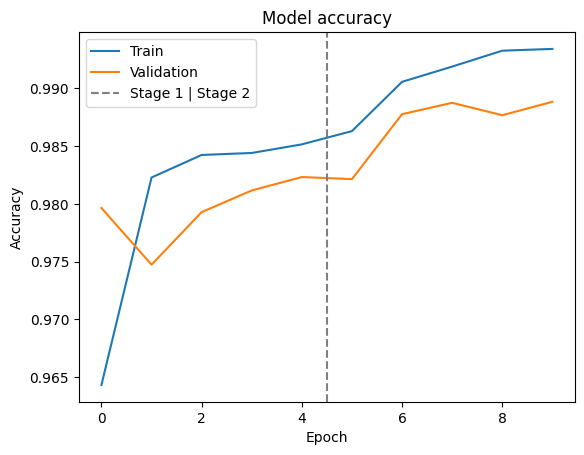

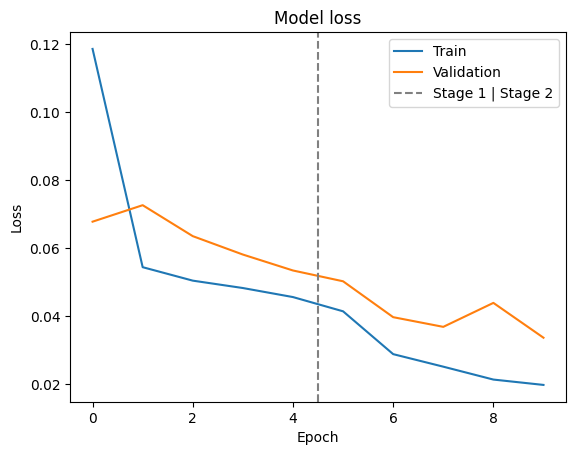

In [ ]:
import matplotlib.pyplot as plt

# Number of epochs in stage 1 (boundary between the two stages)
n_stage1 = history_dict["stage"].count(1) if "stage" in history_dict else None

def plot_metric(metric, title, ylabel):
    plt.plot(history_dict[metric])
    plt.plot(history_dict["val_" + metric])
    if n_stage1 is not None:
        plt.axvline(n_stage1 - 0.5, color="gray", linestyle="--")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation", "Stage 1 | Stage 2"] if n_stage1 is not None else ["Train", "Validation"], loc="best")
    plt.show()

plot_metric("accuracy", "Model accuracy", "Accuracy")
plot_metric("loss", "Model loss", "Loss")

## 9. Model Evaluation

Evaluated on the held-out test set. Precision, recall and F1 are macro-averaged.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

class_names = list(test_generator.class_indices.keys())
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

351/351 [==============================] - 80s 226ms/step
Accuracy : 0.9889
Precision: 0.9891
Recall   : 0.9890
F1-score : 0.9890

              precision    recall  f1-score   support

     Arborio     0.9747    0.9933    0.9839      2250
     Basmati     0.9986    0.9800    0.9892      2250
      Ipsala     0.9982    0.9986    0.9984      2206
     Jasmine     0.9801    0.9836    0.9818      2250
   Karacadag     0.9938    0.9893    0.9915      2250

    accuracy                         0.9889     11206
   macro avg     0.9891    0.9890    0.9890     11206
weighted avg     0.9890    0.9889    0.9889     11206



## 10. Model Prediction

1/1 [==============================] - 0s 438ms/step


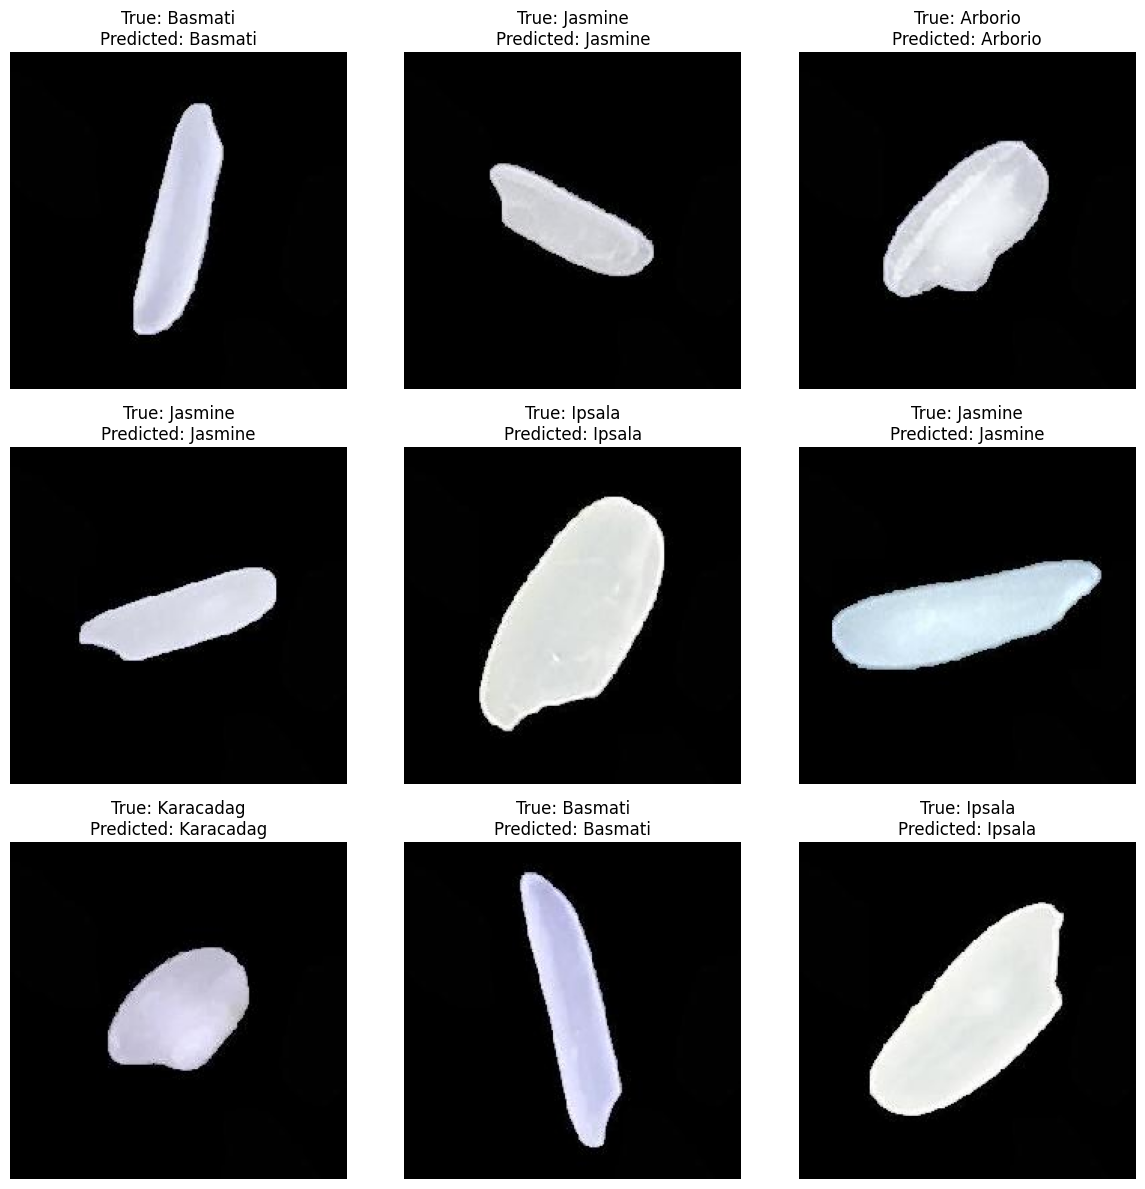

In [ ]:
X_test, y_test = test_generator.next()
predictions = model.predict(X_test)

def plot_predictions(X_test, y_test, predictions, class_indices):
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow((X_test[i] + 1) / 2)   # undo preprocess_input ([-1, 1] -> [0, 1]) for display
        true_label = np.argmax(y_test[i])
        predicted_label = np.argmax(predictions[i])
        true_class = list(class_indices.keys())[list(class_indices.values()).index(true_label)]
        predicted_class = list(class_indices.keys())[list(class_indices.values()).index(predicted_label)]
        plt.title(f"True: {true_class}\nPredicted: {predicted_class}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_predictions(X_test, y_test, predictions, test_generator.class_indices)